# Exploratory Data Analysis on a Cars Dataset

**Dataset:** Vehicle Dataset from CarDekho, file `Car details v3.csv` (Kaggle: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)  
**Goal:** Inspect, clean, describe and visualise used-car listings. No machine-learning model is built.  
**Student:** [Your Name] | **Batch:** [Your Batch]  
**Libraries:** pandas, NumPy, Matplotlib, Seaborn.

**How to run:** keep the dataset CSV in the same folder as this notebook (or set `DATA_PATH` in the setup cell), then choose *Run All*.

## 0. SETUP

In [1]:
%matplotlib inline
import glob
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter
import seaborn as sns

warnings.filterwarnings("ignore")  # keep the output clean (version-related warnings only)

try:                                  # nicer tables inside Jupyter ...
    from IPython.display import display as show
except ImportError:                   # ... plain print when run as a normal .py file
    show = print

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Dataset location. Keep the CSV next to this file, or set DATA_PATH to its full path, e.g.
# DATA_PATH = r"C:\Users\you\Downloads\Car details v3.csv"
DATA_PATH = "Car details v3.csv"

if not os.path.exists(DATA_PATH):
    # Downloads are often renamed (Car_details_v3.csv, Car details v3 (1).csv ...), so look for
    # a v3 file in the current folder and in the Downloads folder.
    search_folders = [os.getcwd(), os.path.join(os.path.expanduser("~"), "Downloads")]
    found = [f for folder in search_folders
             for f in glob.glob(os.path.join(folder, "*[Cc]ar*[Dd]etails*v3*.csv"))]
    if not found:
        raise FileNotFoundError(
            f"Dataset not found. Current folder is: {os.getcwd()}\n"
            "Copy 'Car details v3.csv' into that folder or set DATA_PATH to its full path.")
    DATA_PATH = found[0]
print("Using dataset file:", DATA_PATH)

LAKH = 100_000  # 1 lakh = 100,000 rupees; prices are shown in lakh for readability


def section(title):
    """Print a clear section banner."""
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)

FileNotFoundError: Dataset not found. Current folder is: c:\Users\dsawa\Desktop\unlox
Copy 'Car details v3.csv' into that folder or set DATA_PATH to its full path.

## 1. DATASET OVERVIEW & STRUCTURAL INSPECTION

In [ ]:
section("1. DATASET OVERVIEW")
df = pd.read_csv(DATA_PATH)

print(f"Shape (rows, columns): {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print("\n--- .info() ---")
df.info()
print("\n--- First 5 rows ---")
show(df.head())
print("\n--- Initial data types ---")
print(df.dtypes)
print("\nNote: mileage, engine, max_power and torque are stored as text because they carry units.")

# Required column check - stops early with a clear message if a different CSV was loaded
# (e.g. car_data.csv or car_details_v4.csv have other column names).
required = ["name", "year", "selling_price", "km_driven", "fuel", "seller_type", "transmission",
            "owner", "mileage", "engine", "max_power", "torque", "seats"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"This is not 'Car details v3.csv' - missing columns: {missing_cols}")

# Separate numerical and categorical variables (as stored in the raw file)
raw_numeric = df.select_dtypes(include="number").columns.tolist()
raw_categorical = [c for c in df.columns if c not in raw_numeric]
print("\nNumerical variables  :", raw_numeric)
print("Categorical / text   :", raw_categorical)
print("(mileage, engine, max_power and torque are text for now and become numeric during cleaning)")


1. DATASET OVERVIEW
Shape (rows, columns): (8128, 13)

Columns: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']

--- .info() ---
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float6

## 2. DATA CLEANING & PREPROCESSING (audit trail)

In [ ]:
section("2. DATA CLEANING")

# ---- 2.1 Record size BEFORE cleaning --------------------------------------
rows_before, cols_before = df.shape
print(f"Dimensions BEFORE cleaning: {rows_before} rows x {cols_before} columns")

# ---- 2.2 Duplicates --------------------------------------------------------
# Rows identical in ALL columns (same name, year, price, km, owner, ...) carry no new
# information and would over-weight popular listings, so they are dropped.
n_duplicates = int(df.duplicated().sum())
print(f"\nExact duplicate rows found: {n_duplicates} ({n_duplicates / rows_before:.1%})")
df = df.drop_duplicates().reset_index(drop=True)
rows_after_dedup = len(df)
print(f"Rows after dropping duplicates: {rows_after_dedup}")

# ---- 2.3 Inconsistent labels ----------------------------------------------
# Strip stray whitespace from every text column so that 'Diesel ' and 'Diesel' match.
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.strip()

# Inconsistent-category check: list the unique labels of every small categorical column.
# Each label should appear exactly once (no 'diesel' vs 'Diesel', no stray spaces).
print("\nLabel check after trimming spaces:")
for col in ["fuel", "seller_type", "transmission", "owner"]:
    print(f"  {col}: {sorted(df[col].unique())}")
print("  -> labels are consistent. 'Test Drive Car' (only 5 rows) is a valid but rare owner category, so it is kept.")

# ---- 2.4 Feature extraction: brand ----------------------------------------
# The first word of 'name' is the manufacturer. Two brands are two words long and would
# otherwise be truncated ('Land' -> Land Rover, 'Ashok' -> Ashok Leyland).
df["brand"] = df["name"].str.split().str[0]
df["brand"] = df["brand"].replace({"Land": "Land Rover", "Ashok": "Ashok Leyland"})
print(f"\nBrands extracted: {df['brand'].nunique()} unique manufacturers")
print(sorted(df["brand"].unique()))  # eyeball the list for spelling variants - none found

# ---- 2.5 Unit stripping -> numeric floats ----------------------------------
# Remember which unit mileage used: petrol/diesel are in kmpl, CNG/LPG in km/kg.
df["mileage_unit"] = df["mileage"].str.extract(r"(kmpl|km/kg)")[0]
print("\nMileage units present:\n", df["mileage_unit"].value_counts(dropna=False))

# A regex that keeps only the leading number removes 'kmpl', 'km/kg', 'CC' and 'bhp' in one
# step, and returns NaN (not an error) for blank values such as ' bhp'.
for col in ["mileage", "engine", "max_power"]:
    df[col] = pd.to_numeric(df[col].str.extract(r"(\d+\.?\d*)")[0], errors="coerce")

# A mileage of 0 is physically impossible for a running car -> treat as missing.
n_zero_mileage = int((df["mileage"] == 0).sum())
df.loc[df["mileage"] == 0, "mileage"] = np.nan
print(f"Mileage values equal to 0 converted to NaN: {n_zero_mileage}")

# Likewise, 0 bhp is impossible for a working engine (e.g. Maruti Alto K10 with a 998 cc engine).
n_zero_power = int((df["max_power"] == 0).sum())
df.loc[df["max_power"] == 0, "max_power"] = np.nan
print(f"max_power values equal to 0 converted to NaN: {n_zero_power}")

# ---- 2.6 Drop 'torque' ------------------------------------------------------
# 'torque' mixes units (Nm, kgm) and formats ('190Nm@ 2000rpm', '12.7@ 2,700(kgm@ rpm)',
# rpm ranges). A reliable single number cannot be extracted without guesswork, and
# engine / max_power already describe performance, so the column is dropped.
df = df.drop(columns=["torque"])
print("Dropped column: torque (inconsistent units, not safely parseable)")

# ---- 2.7 Missing-value audit ------------------------------------------------
section("2.7 MISSING VALUE AUDIT (before treatment)")
missing = pd.DataFrame({"null_count": df.isna().sum(),
                        "null_pct": (df.isna().mean() * 100).round(2)})
show(missing[missing["null_count"] > 0])
print("\nKey observation: almost the same rows are missing mileage, engine, max_power and seats, "
      "i.e. the gaps come from incomplete listings rather than from one specific brand or fuel.")

# Treatment: only ~3% of rows are affected, so dropping them would also be acceptable, but
# imputing keeps the sample size. Median is used (robust to the skew seen in max_power) and
# it is taken within brand + fuel, because cars from the same maker with the same fuel have
# similar engines and efficiency. Fallback: fuel median, then overall median.
means_before = df[["mileage", "engine", "max_power", "seats"]].mean().round(2)
for col in ["mileage", "engine", "max_power", "seats"]:
    brand_fuel_median = df.groupby(["brand", "fuel"])[col].transform("median")
    fuel_median = df.groupby("fuel")[col].transform("median")
    df[col] = df[col].fillna(brand_fuel_median).fillna(fuel_median).fillna(df[col].median())
df["seats"] = df["seats"].round().astype(int)  # seats is a whole number
means_after = df[["mileage", "engine", "max_power", "seats"]].mean().round(2)

print("\nColumn means before vs after imputation (should barely move):")
show(pd.DataFrame({"before": means_before, "after": means_after}))
# Imputed rows take the unit that matches their fuel (CNG/LPG are quoted in km/kg).
df["mileage_unit"] = df["mileage_unit"].fillna(df["fuel"].map(lambda f: "km/kg" if f in ("CNG", "LPG") else "kmpl"))
print(f"\nRemaining missing values: {int(df.isna().sum().sum())}")

# ---- 2.8 Feature engineering: car age --------------------------------------
# Newest model year in the data (2020) is used as the reference so age is never negative.
REFERENCE_YEAR = df["year"].max()
df["car_age"] = REFERENCE_YEAR - df["year"]

# ---- 2.9 Outlier detection (IQR rule) -------------------------------------
section("2.9 OUTLIER DETECTION (IQR method)")


def iqr_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((series < low) | (series > high)).sum())
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "lower_fence": low, "upper_fence": high,
            "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(series), 2)}


outlier_table = pd.DataFrame({c: iqr_summary(df[c])
                              for c in ["selling_price", "km_driven", "max_power"]}).T
show(outlier_table.round(1))

# Treatment decision:
#  * selling_price and max_power outliers are luxury / high-performance cars (Volvo XC90, BMW X7,
#    Audi A6 ...). They are real records, so they are KEPT and handled with log scales in charts.
#  * km_driven has two impossible entries (> 1,000,000 km on a 10-year-old hatchback/SUV) that
#    look like typing errors. Only these are removed.
KM_LIMIT = 1_000_000
bad_km = df[df["km_driven"] > KM_LIMIT]
print(f"\nRecords with km_driven > {KM_LIMIT:,} (data-entry errors) removed: {len(bad_km)}")
print(bad_km[["name", "year", "selling_price", "km_driven"]].to_string(index=False))
df = df[df["km_driven"] <= KM_LIMIT].reset_index(drop=True)

# Convert price to lakh for plotting / reporting
df["price_lakh"] = df["selling_price"] / LAKH

# ---- 2.10 Dimensions AFTER cleaning (audit trail) ------------------------
section("2.10 AUDIT TRAIL")
rows_final, cols_final = df.shape
audit = pd.DataFrame({
    "Step": ["Raw data", "After dropping duplicates", "After km_driven fix + feature changes"],
    "Rows": [rows_before, rows_after_dedup, rows_final],
    "Columns": [cols_before, cols_before, cols_final],
})
show(audit)
print(f"Dimensions AFTER cleaning: {rows_final} rows x {cols_final} columns")
print(f"Rows removed in total: {rows_before - rows_final} "
      f"({(rows_before - rows_final) / rows_before:.1%}) | "
      f"columns: 'torque' dropped; 'brand', 'mileage_unit', 'car_age', 'price_lakh' added")
print("\nCleaned data types:")
print(df.dtypes)


2. DATA CLEANING
Dimensions BEFORE cleaning: 8128 rows x 13 columns

Exact duplicate rows found: 1202 (14.8%)
Rows after dropping duplicates: 6926

Label check after trimming spaces:
  fuel: ['CNG', 'Diesel', 'LPG', 'Petrol']
  seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
  transmission: ['Automatic', 'Manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']
  -> labels are consistent. 'Test Drive Car' (only 5 rows) is a valid but rare owner category, so it is kept.

Brands extracted: 32 unique manufacturers
['Ambassador', 'Ashok Leyland', 'Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Opel', 'Peugeot', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']

Mileage units present:
 mileage_unit
kmpl     6631
NaN       208
km/kg      87
Name: count

## 3. DESCRIPTIVE STATISTICAL ANALYSIS

In [ ]:
section("3. DESCRIPTIVE STATISTICS")
numeric_cols = ["year", "selling_price", "km_driven", "mileage", "engine", "max_power", "seats"]
categorical_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]
print("Numerical variables (after cleaning)  :", numeric_cols)
print("Categorical variables (after cleaning):", categorical_cols)
print()

# ---- 3.1 Numerical ----------------------------------------------------------
desc = df[numeric_cols].describe().T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["median"] = df[numeric_cols].median()
desc["skewness"] = df[numeric_cols].skew()
show(desc[["mean", "median", "std", "min", "25%", "75%", "max", "IQR", "skewness"]].round(2))

# ---- 3.2 Categorical --------------------------------------------------------
print("\nCardinality of categorical features:")
print(df[categorical_cols].nunique())
for col in ["brand", "fuel", "transmission", "owner", "seller_type"]:
    counts = df[col].value_counts()
    freq = pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)})
    print(f"\nFrequency of '{col}':")
    show(freq.head(10) if col == "brand" else freq)

# ---- 3.3 Bivariate summaries (used later in the findings) ------------------
brand_stats = df.groupby("brand")["selling_price"].agg(["count", "mean", "median"])
brand_stats = brand_stats[brand_stats["count"] >= 30].sort_values("mean", ascending=False)
print("\nAverage price (rupees) by brand (brands with >= 30 listings), top 5:")
show(brand_stats.head(5).round(0))
print("\nMedian price (rupees) by owner type:")
print(df.groupby("owner")["selling_price"].median())


3. DESCRIPTIVE STATISTICS
Numerical variables (after cleaning)  : ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical variables (after cleaning): ['brand', 'fuel', 'seller_type', 'transmission', 'owner']

                    mean     median        std      min       25%        75%         max        IQR  skewness
year             2013.42    2014.00       4.08   1983.0    2011.0    2017.00      2020.0       6.00     -1.01
selling_price  517268.45  400000.00  519841.87  29999.0  250000.0  634250.00  10000000.0  384250.00      5.57
km_driven       73459.50   70000.00   48553.93      1.0   40000.0  100000.00    577414.0   60000.00      1.71
mileage            19.48      19.40       3.93      9.0      16.8      22.32        42.0       5.52      0.06
engine           1431.53    1248.00     493.74    624.0    1197.0    1498.00      3604.0     301.00      1.21
max_power          87.64      81.83      31.41     32.8      68.0     100.00       400.0    

## 4. VISUAL EDA  (6 charts, 6 chart types)


4. VISUAL EDA


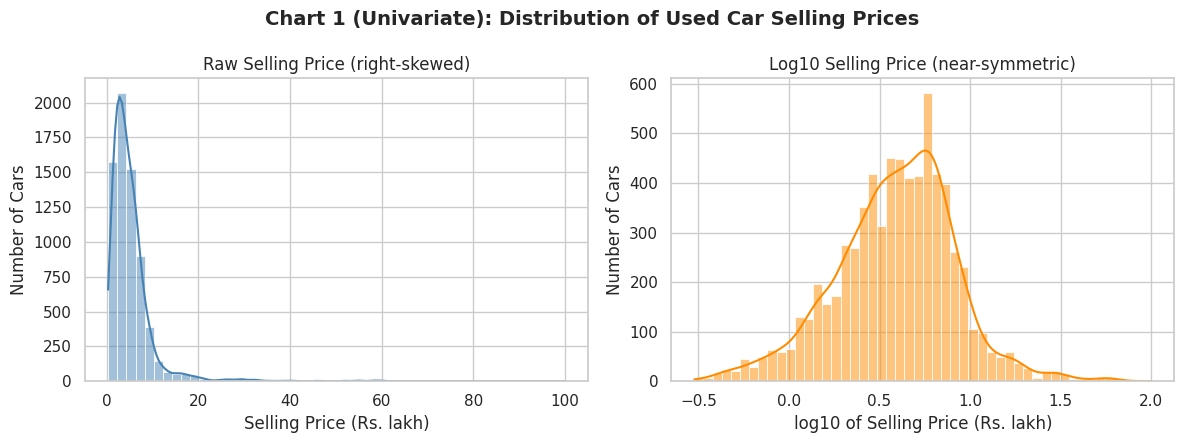

Observation: Prices are strongly right-skewed (skewness = 5.57); the mean (Rs. 5.17 lakh) sits well above the median (Rs. 4.00 lakh).
After a log transform the skewness falls to -0.16, so the log scale is better for comparing groups. Most cars sell below Rs. 6.3 lakh.


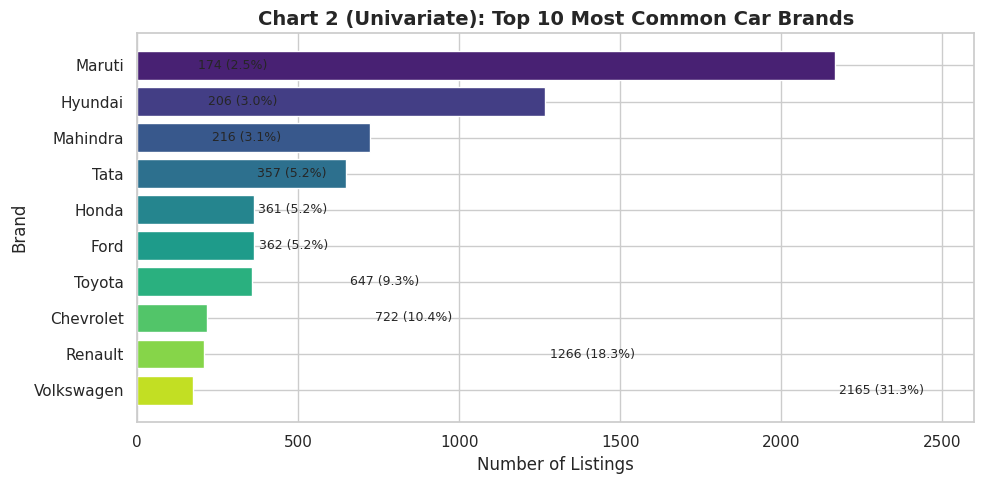

Observation: Maruti (2165 cars) and Hyundai (1266 cars) together make up 49.6% of all listings.
The top 10 brands cover 93.5% of the data, so the market is dominated by mass-market brands and luxury marques are rare.


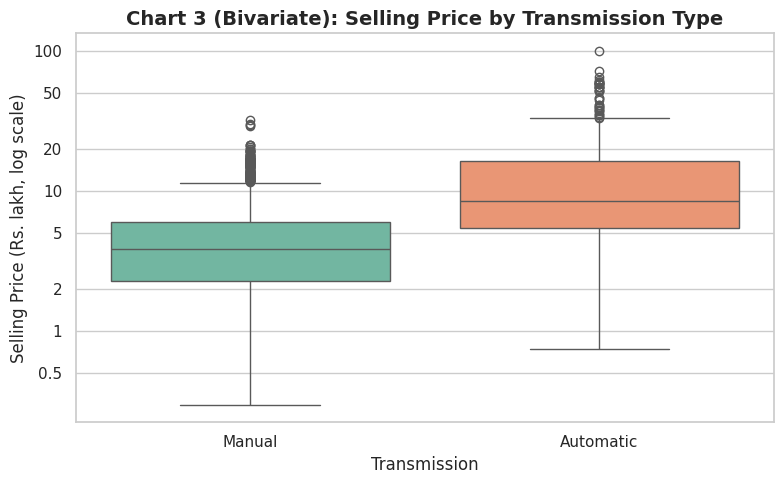

Observation: The median automatic car costs Rs. 8.50 lakh versus Rs. 3.85 lakh for manual - about 2.2x higher.
Automatics are only 8.4% of listings and are newer (median year 2016 vs 2014) and more powerful (124 vs 82 bhp), so part of the gap is not the gearbox alone.


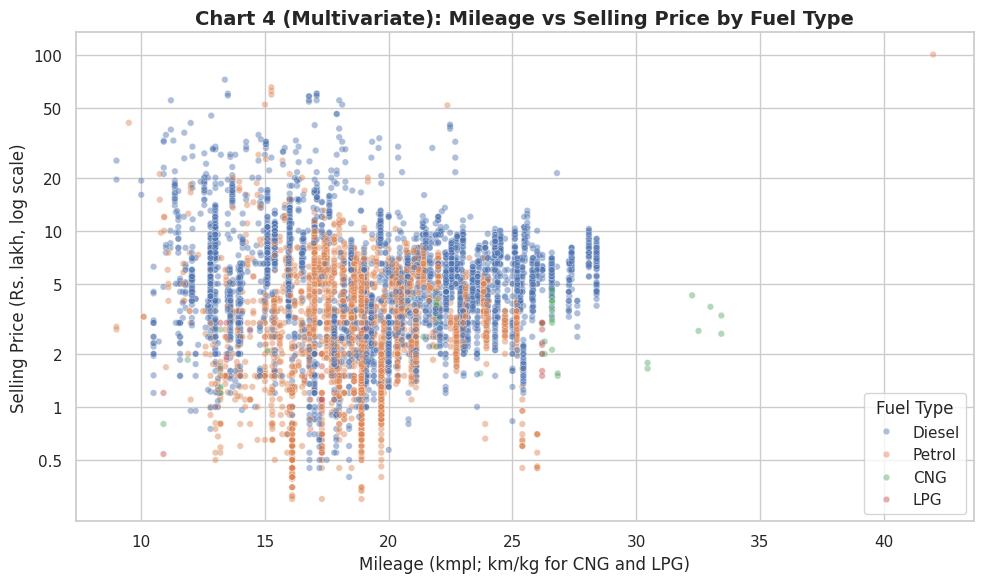

Observation: Overall correlation between mileage and price is weak (-0.10); it is -0.16 for diesel and -0.03 for petrol cars.
The cloud is wide at every mileage level, so mileage alone does not explain price. CNG/LPG points are measured in km/kg and are few, so they are not directly comparable.


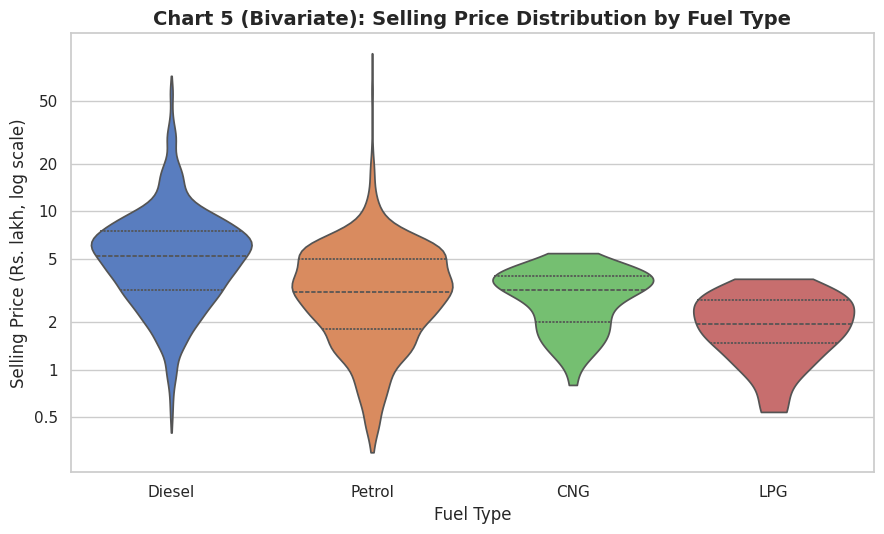

Observation: Diesel cars have the highest median price (Rs. 5.20 lakh) followed by Petrol (Rs. 3.10 lakh); CNG (3.20) and LPG (1.96) are the cheapest.
CNG (56) and LPG (38) have very few records, so their shapes are indicative only. Diesel also has the longer upper tail (95th percentile Rs. 15.7 lakh vs Rs. 7.8 lakh for petrol).


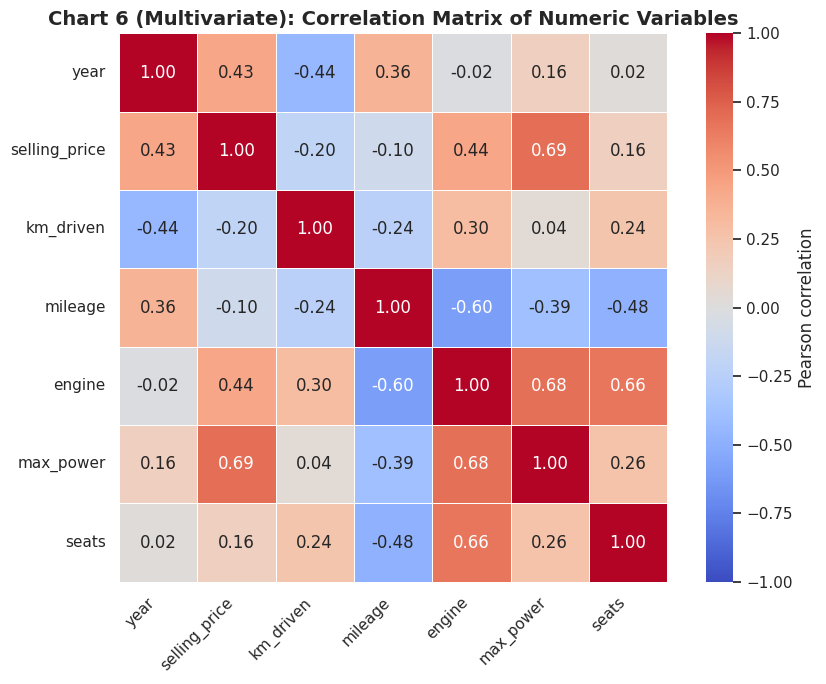

Observation: Price correlates most strongly with max_power (0.69), year (0.43) and engine (0.44); km_driven (-0.20) and mileage (-0.10) are negative.
Engine and max_power are highly inter-correlated (0.68), and year is negatively related to km_driven (-0.44), i.e. newer cars tend to have fewer kilometres.


In [ ]:
section("4. VISUAL EDA")

# ---- Chart 1: Histogram + KDE of price (raw vs log) -------------------------
skew_raw = df["price_lakh"].skew()
skew_log = np.log10(df["price_lakh"]).skew()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["price_lakh"], bins=50, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Raw Selling Price (right-skewed)")
axes[0].set_xlabel("Selling Price (Rs. lakh)")
axes[0].set_ylabel("Number of Cars")
sns.histplot(np.log10(df["price_lakh"]), bins=50, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Log10 Selling Price (near-symmetric)")
axes[1].set_xlabel("log10 of Selling Price (Rs. lakh)")
axes[1].set_ylabel("Number of Cars")
fig.suptitle("Chart 1 (Univariate): Distribution of Used Car Selling Prices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Observation: Prices are strongly right-skewed (skewness = {skew_raw:.2f}); the mean "
      f"(Rs. {df['price_lakh'].mean():.2f} lakh) sits well above the median "
      f"(Rs. {df['price_lakh'].median():.2f} lakh).")
print(f"After a log transform the skewness falls to {skew_log:.2f}, so the log scale is better "
      f"for comparing groups. Most cars sell below Rs. {df['price_lakh'].quantile(0.75):.1f} lakh.")

# ---- Chart 2: Top 10 brands (bar / count plot) -----------------------------
top_brands = df["brand"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_brands.index[::-1], top_brands.values[::-1],
        color=sns.color_palette("viridis", len(top_brands))[::-1])
for i, v in enumerate(top_brands.values):
    ax.text(v + 15, i, f"{v} ({v / len(df):.1%})", va="center", fontsize=9)
ax.set_title("Chart 2 (Univariate): Top 10 Most Common Car Brands", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("Brand")
ax.set_xlim(0, top_brands.max() * 1.2)
plt.tight_layout()
plt.show()
top2_share = top_brands.head(2).sum() / len(df)
top10_share = top_brands.sum() / len(df)
print(f"Observation: {top_brands.index[0]} ({top_brands.iloc[0]} cars) and {top_brands.index[1]} "
      f"({top_brands.iloc[1]} cars) together make up {top2_share:.1%} of all listings.")
print(f"The top 10 brands cover {top10_share:.1%} of the data, so the market is dominated by "
      f"mass-market brands and luxury marques are rare.")

# ---- Chart 3: Box plot of price by transmission ----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="transmission", y="price_lakh", order=["Manual", "Automatic"],
            palette=["#66c2a5", "#fc8d62"], ax=ax)
ax.set_yscale("log")
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
ax.set_yticklabels(["0.5", "1", "2", "5", "10", "20", "50", "100"])
ax.yaxis.set_minor_formatter(NullFormatter())  # hide cluttered minor tick labels
ax.set_title("Chart 3 (Bivariate): Selling Price by Transmission Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Transmission")
ax.set_ylabel("Selling Price (Rs. lakh, log scale)")
plt.tight_layout()
plt.show()
med_t = df.groupby("transmission")["selling_price"].median()
n_t = df["transmission"].value_counts()
print(f"Observation: The median automatic car costs Rs. {med_t['Automatic'] / LAKH:.2f} lakh versus "
      f"Rs. {med_t['Manual'] / LAKH:.2f} lakh for manual - about {med_t['Automatic'] / med_t['Manual']:.1f}x higher.")
tr = df.groupby("transmission")[["year", "max_power"]].median()
print(f"Automatics are only {n_t['Automatic'] / len(df):.1%} of listings and are newer (median year "
      f"{tr.loc['Automatic', 'year']:.0f} vs {tr.loc['Manual', 'year']:.0f}) and more powerful "
      f"({tr.loc['Automatic', 'max_power']:.0f} vs {tr.loc['Manual', 'max_power']:.0f} bhp), so part of the gap is not the gearbox alone.")

# ---- Chart 4: Scatter - mileage vs price, coloured by fuel -----------------
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="mileage", y="price_lakh", hue="fuel", alpha=0.45, s=22,
                hue_order=["Diesel", "Petrol", "CNG", "LPG"], ax=ax)
ax.set_yscale("log")
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
ax.set_yticklabels(["0.5", "1", "2", "5", "10", "20", "50", "100"])
ax.yaxis.set_minor_formatter(NullFormatter())  # hide cluttered minor tick labels
ax.set_title("Chart 4 (Multivariate): Mileage vs Selling Price by Fuel Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Mileage (kmpl; km/kg for CNG and LPG)")
ax.set_ylabel("Selling Price (Rs. lakh, log scale)")
ax.legend(title="Fuel Type")
plt.tight_layout()
plt.show()
corr_all = df["mileage"].corr(df["selling_price"])
corr_diesel = df.loc[df["fuel"] == "Diesel", "mileage"].corr(df.loc[df["fuel"] == "Diesel", "selling_price"])
corr_petrol = df.loc[df["fuel"] == "Petrol", "mileage"].corr(df.loc[df["fuel"] == "Petrol", "selling_price"])
print(f"Observation: Overall correlation between mileage and price is weak ({corr_all:.2f}); it is "
      f"{corr_diesel:.2f} for diesel and {corr_petrol:.2f} for petrol cars.")
print("The cloud is wide at every mileage level, so mileage alone does not explain price. "
      "CNG/LPG points are measured in km/kg and are few, so they are not directly comparable.")

# ---- Chart 5: Violin plot of price across fuel types -----------------------
df["log_price"] = np.log10(df["price_lakh"])
fuel_order = ["Diesel", "Petrol", "CNG", "LPG"]
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(data=df, x="fuel", y="log_price", order=fuel_order,
               palette=sns.color_palette("muted", 4), inner="quartile", cut=0, ax=ax)
tick_vals = [0.5, 1, 2, 5, 10, 20, 50]
ax.set_yticks(np.log10(tick_vals))
ax.set_yticklabels([str(t) for t in tick_vals])
ax.set_title("Chart 5 (Bivariate): Selling Price Distribution by Fuel Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Selling Price (Rs. lakh, log scale)")
plt.tight_layout()
plt.show()
med_f = df.groupby("fuel")["selling_price"].median() / LAKH
n_f = df["fuel"].value_counts()
print(f"Observation: Diesel cars have the highest median price (Rs. {med_f['Diesel']:.2f} lakh) "
      f"followed by Petrol (Rs. {med_f['Petrol']:.2f} lakh); CNG ({med_f['CNG']:.2f}) and "
      f"LPG ({med_f['LPG']:.2f}) are the cheapest.")
p95 = df.groupby("fuel")["price_lakh"].quantile(0.95)
print(f"CNG ({n_f['CNG']}) and LPG ({n_f['LPG']}) have very few records, so their shapes are "
      f"indicative only. Diesel also has the longer upper tail (95th percentile Rs. {p95['Diesel']:.1f} "
      f"lakh vs Rs. {p95['Petrol']:.1f} lakh for petrol).")

# ---- Chart 6: Correlation heatmap -------------------------------------------
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
            linewidths=0.5, square=True, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Chart 6 (Multivariate): Correlation Matrix of Numeric Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
price_corr = corr["selling_price"].drop("selling_price").sort_values(ascending=False)
print(f"Observation: Price correlates most strongly with max_power ({price_corr['max_power']:.2f}), "
      f"year ({price_corr['year']:.2f}) and engine ({price_corr['engine']:.2f}); km_driven "
      f"({price_corr['km_driven']:.2f}) and mileage ({price_corr['mileage']:.2f}) are negative.")
print(f"Engine and max_power are highly inter-correlated ({corr.loc['engine', 'max_power']:.2f}), and "
      f"year is negatively related to km_driven ({corr.loc['year', 'km_driven']:.2f}), i.e. "
      f"newer cars tend to have fewer kilometres.")

## 5. KEY FINDINGS (every number below is computed from the cleaned data)

In [ ]:
section("5. KEY FINDINGS")

# Finding 1 - market composition
diesel_share = (df["fuel"] == "Diesel").mean()
print(f"1. Market is concentrated: {top_brands.index[0]} and {top_brands.index[1]} hold {top2_share:.1%} "
      f"of listings; diesel ({diesel_share:.1%}) and petrol ({(df['fuel'] == 'Petrol').mean():.1%}) "
      f"cars make up almost everything.")

# Finding 2 - price distribution
print(f"2. Prices are right-skewed: mean Rs. {df['price_lakh'].mean():.2f} lakh vs median "
      f"Rs. {df['price_lakh'].median():.2f} lakh (skewness {skew_raw:.2f} -> {skew_log:.2f} after log).")

# Finding 3 - age and price
corr_age = df["car_age"].corr(df["selling_price"])
young = df.loc[df["car_age"] <= 3, "selling_price"].median() / LAKH
old = df.loc[df["car_age"] >= 10, "selling_price"].median() / LAKH
print(f"3. Newer cars sell for more: car age is negatively correlated with price (r = {corr_age:.2f}); median price "
      f"is Rs. {young:.2f} lakh for cars <= 3 years old vs Rs. {old:.2f} lakh for cars >= 10 years old.")

# Finding 4 - transmission
print(f"4. Automatic cars cost about {med_t['Automatic'] / med_t['Manual']:.1f}x the manual median "
      f"(Rs. {med_t['Automatic'] / LAKH:.2f} vs Rs. {med_t['Manual'] / LAKH:.2f} lakh) - but they are "
      f"newer (median year {tr.loc['Automatic', 'year']:.0f} vs {tr.loc['Manual', 'year']:.0f}) and more powerful, "
      f"so this is association, not proof of a gearbox premium.")

# Finding 5 - power vs price, and brand
print(f"5. Power is the strongest price correlate (max_power r = {price_corr['max_power']:.2f}); "
      f"mileage is only weakly (negatively) related (r = {price_corr['mileage']:.2f}). Highest average prices belong to "
      f"{', '.join(brand_stats.index[:3])}, far above Maruti "
      f"(Rs. {df.loc[df['brand'] == 'Maruti', 'price_lakh'].mean():.2f} lakh average).")

print("\nLimitations: (1) no accident/service history or exact condition, (2) listings are spread "
      "over many years with no listing date, so inflation and time effects are mixed in, "
      "(3) data comes from one platform and mostly Indian mass-market cars, so results may not "
      "generalise; CNG, LPG and luxury brands have small samples.")
print("\nEDA complete.")


5. KEY FINDINGS
1. Market is concentrated: Maruti and Hyundai hold 49.6% of listings; diesel (54.2%) and petrol (44.4%) cars make up almost everything.
2. Prices are right-skewed: mean Rs. 5.17 lakh vs median Rs. 4.00 lakh (skewness 5.57 -> -0.16 after log).
3. Newer cars sell for more: car age is negatively correlated with price (r = -0.43); median price is Rs. 6.55 lakh for cars <= 3 years old vs Rs. 1.60 lakh for cars >= 10 years old.
4. Automatic cars cost about 2.2x the manual median (Rs. 8.50 vs Rs. 3.85 lakh) - but they are newer (median year 2016 vs 2014) and more powerful, so this is association, not proof of a gearbox premium.
5. Power is the strongest price correlate (max_power r = 0.69); mileage is only weakly (negatively) related (r = -0.10). Highest average prices belong to BMW, Audi, Mercedes-Benz, far above Maruti (Rs. 3.88 lakh average).

Limitations: (1) no accident/service history or exact condition, (2) listings are spread over many years with no listing date, so i